# Sparkify project - churn prediction modeling
This problem can be seen as a classification problem.
Given a data collection window of 60 days for a set of registered users, let's assess which users are likely to churn.
Several classification algorithm will be used and tested against a baseline model given two performance metrics.

Baseline model: 
Nobody churns

Performance metrics: 
- Accuracy 
- F1 score 

Models to test:
- Logistic Regression
- Naive Bayes
- Random Forest 
- Support Vector Machines

In [1]:
# import libraries
from pyspark.sql import SparkSession
from pyspark.sql import Window
from pyspark.sql.functions import udf, concat, lit, col , explode, array, least
from pyspark.sql.functions import isnan, when
from pyspark.sql.functions import sum as Fsum 
from pyspark.sql.functions import min as Fmin
from pyspark.sql.functions import max as Fmax
from pyspark.sql.functions import unix_timestamp, to_timestamp, datediff
from pyspark.sql.functions import avg, stddev , count
from pyspark.sql.functions import asc, desc, log
from pyspark.sql.types import IntegerType, StringType, DoubleType, LongType, BooleanType, TimestampType, DateType
from pyspark.ml.feature import RegexTokenizer, VectorAssembler, MinMaxScaler
from pyspark.ml.classification import GBTClassifier, RandomForestClassifier, LinearSVC, LogisticRegression, NaiveBayes
from pyspark.ml.classification import GBTClassificationModel, RandomForestClassificationModel, LinearSVCModel, LogisticRegressionModel, NaiveBayesModel
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns 
import scipy.stats as sp
from datetime import datetime as dt 
from datetime import timedelta as td
import itertools
import time

In [2]:
# create a Spark session
spark = SparkSession.builder \
        .master("local") \
        .appName("Sparkify_Modelling") \
        .getOrCreate()

In [3]:
# Utility functions
def load_df(filename):
    df = spark.read.json(data_path)
    return df 

# Loading user dataset with features and labels

In [4]:
data_path = "mini_sparkify_features.json"

In [5]:
data = load_df(data_path)

In [6]:
data.persist()

DataFrame[About: bigint, Add Friend: bigint, Add to Playlist: bigint, Downgrade: bigint, Error: bigint, Help: bigint, Home: bigint, Logout: bigint, NextSong: bigint, Roll Advert: bigint, Save Settings: bigint, Settings: bigint, Submit Downgrade: bigint, Submit Upgrade: bigint, Thumbs Down: bigint, Thumbs Up: bigint, Upgrade: bigint, active_days_count: bigint, free_sessions: bigint, free_sessions_length: double, gender: bigint, paid_session_share: double, paid_sessions: bigint, paid_sessions_length: double, session_count: bigint, song_count: bigint, tenure: bigint, total_length: double, userId: string, user_churn_flag: bigint]

In [7]:
data.count()

220

# Modeling
Let's split the full dataset into train, test, and validation sets, test the models listed earlier, evaluate the performance against F1 score and accuracy and determine the winner.

# Feature transformation and scaling

In [8]:
features = data.drop('userId')

In [9]:
features.printSchema()

root
 |-- About: long (nullable = true)
 |-- Add Friend: long (nullable = true)
 |-- Add to Playlist: long (nullable = true)
 |-- Downgrade: long (nullable = true)
 |-- Error: long (nullable = true)
 |-- Help: long (nullable = true)
 |-- Home: long (nullable = true)
 |-- Logout: long (nullable = true)
 |-- NextSong: long (nullable = true)
 |-- Roll Advert: long (nullable = true)
 |-- Save Settings: long (nullable = true)
 |-- Settings: long (nullable = true)
 |-- Submit Downgrade: long (nullable = true)
 |-- Submit Upgrade: long (nullable = true)
 |-- Thumbs Down: long (nullable = true)
 |-- Thumbs Up: long (nullable = true)
 |-- Upgrade: long (nullable = true)
 |-- active_days_count: long (nullable = true)
 |-- free_sessions: long (nullable = true)
 |-- free_sessions_length: double (nullable = true)
 |-- gender: long (nullable = true)
 |-- paid_session_share: double (nullable = true)
 |-- paid_sessions: long (nullable = true)
 |-- paid_sessions_length: double (nullable = true)
 |-- se

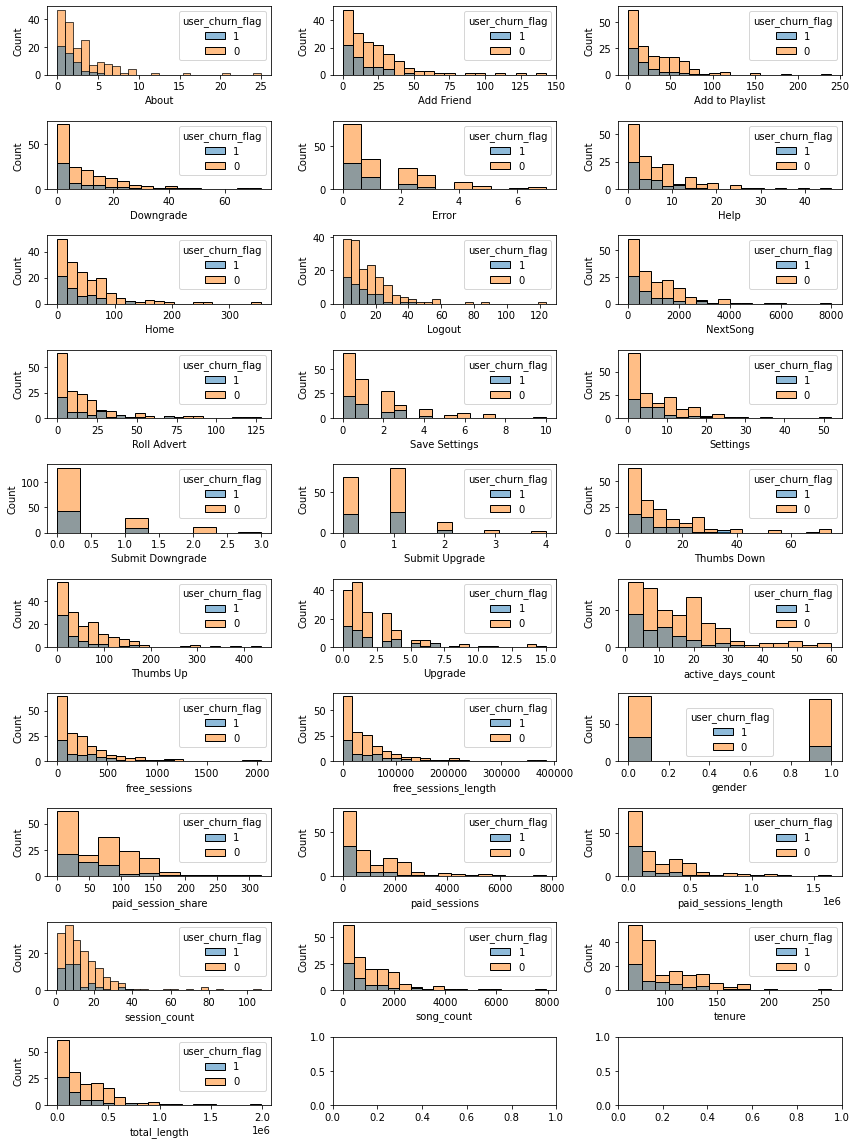

In [10]:
# Check feature distributions
feature_names = features.columns[:-1]
feature_count = len(feature_names)
ny = 3
nx, r = divmod(feature_count, ny)
if r != 0:
    nx = nx+ 1
indices = list(itertools.product(range(nx), range(ny)))
fig, ax = plt.subplots(nx,ny, figsize = [12,16])

for i,f in enumerate(feature_names):
    ix, iy = indices[i]
    feature = features.select(f,'user_churn_flag').toPandas()
    axi = ax[ix][iy]
    sns.histplot(feature,x=f, hue='user_churn_flag', ax = axi, hue_order=[1,0])
    #axi.set_title(f)
    plt.tight_layout()

In [14]:
# Feature scaling 
def feature_scaling(df):
    
    # extract feature names
    features = df.columns[:-1]
    
    # apply logarithm transformation
    df_log = df.select(*[log(col(col_name)+lit(1)).alias(col_name) for col_name in features],'user_churn_flag')
    
    # assemble features in a vector
    assembler = VectorAssembler(inputCols=df.columns[:-1], outputCol="FeatureVec")
    df_vec = assembler.transform(df_log)
    df_vec = df_vec.select(col("FeatureVec").alias("features"),col('user_churn_flag').alias('label'))
    
    # scale features
    min_max_scaler = MinMaxScaler(inputCol = "features", outputCol = "FeatureVecScaled")
    scalerModel = min_max_scaler.fit(df_vec)
    df_scaled = scalerModel.transform(df_vec)
    df_scaled = df_scaled.select(col("FeatureVecScaled").alias("features"),col('label'))
    
    return df_scaled

In [15]:
feature_scaled = feature_scaling(features)

In [16]:
feature_scaled.persist()

DataFrame[features: vector, label: bigint]

In [17]:
def get_n_el(x,n):
    return x[n]

def select_el_udf(n):
    return udf(lambda x:float(get_n_el(x,n)), DoubleType())

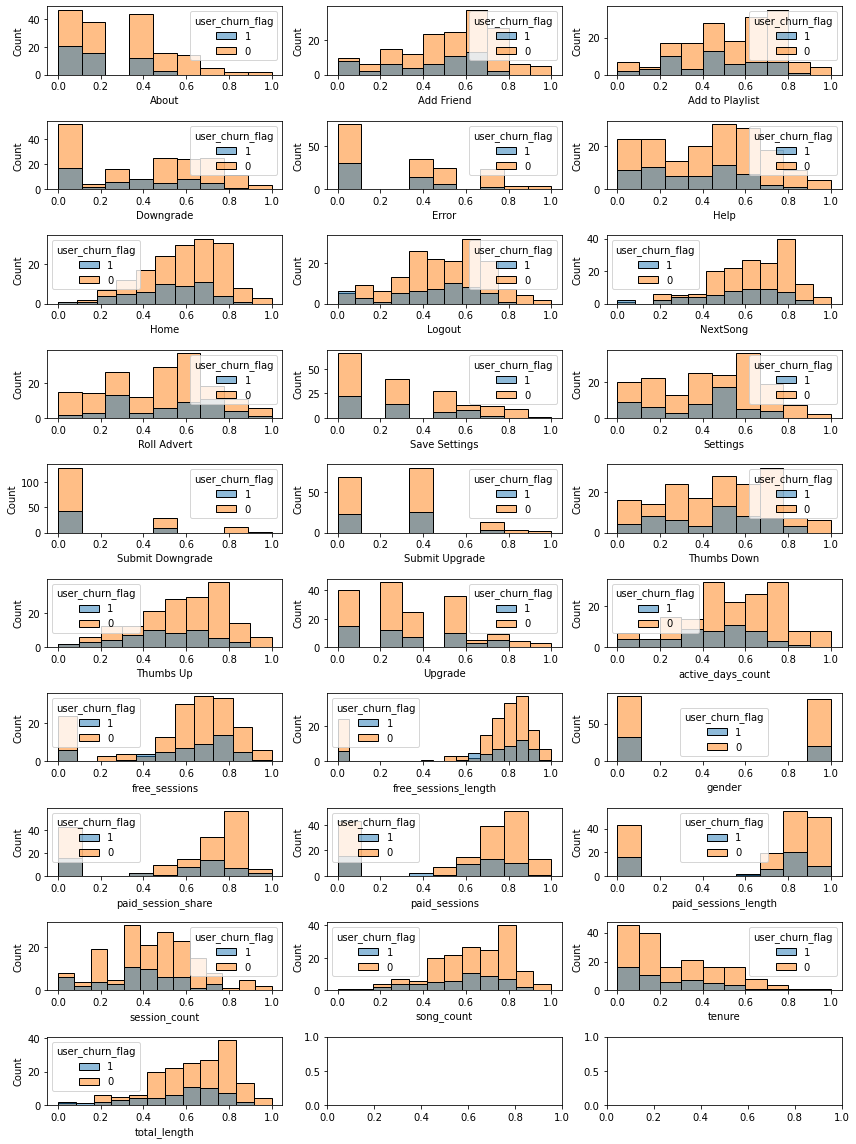

In [18]:
# Check feature scaled distributions
fig, ax = plt.subplots(nx,ny, figsize = [12,16])

for i,f in enumerate(feature_names):
    ix, iy = indices[i]
    feature = feature_scaled.select(select_el_udf(i)(col('features')).alias(f),col('label').alias('user_churn_flag')).toPandas()
    axi = ax[ix][iy]
    sns.histplot(feature,x=f, hue='user_churn_flag', ax = axi, hue_order=[1,0])
    #axi.set_title(f)
    plt.tight_layout()

In [19]:
feature_scaled.printSchema()

root
 |-- features: vector (nullable = true)
 |-- label: long (nullable = true)



In [20]:
# Churn proportion on full dataset
feature_scaled.select('label').agg(avg('label')).show()

+-------------------+
|         avg(label)|
+-------------------+
|0.23636363636363636|
+-------------------+



In [132]:
# Split training and validation datasets
training_dataset, validation_dataset = feature_scaled.randomSplit([0.8,0.2])

In [133]:
# Churn proportion on training dataset
training_dataset.select('label').agg(avg('label')).show()

+-------------------+
|         avg(label)|
+-------------------+
|0.23976608187134502|
+-------------------+



In [134]:
# Churn proportion on validation dataset
validation_dataset.select('label').agg(avg('label')).show()

+-------------------+
|         avg(label)|
+-------------------+
|0.22448979591836735|
+-------------------+



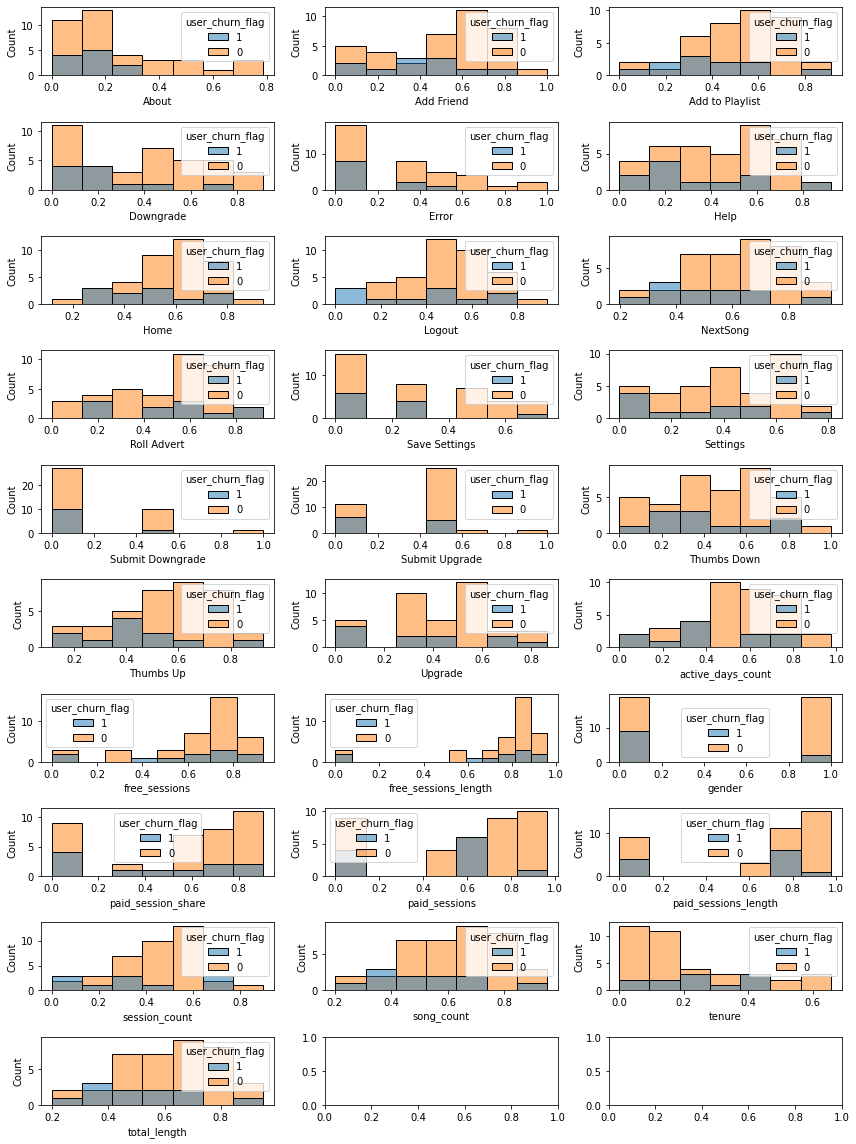

In [138]:
# Check validation dataset distributions
fig, ax = plt.subplots(nx,ny, figsize = [12,16])

for i,f in enumerate(feature_names):
    ix, iy = indices[i]
    feature = validation_dataset.select(select_el_udf(i)(col('features')).alias(f),col('label').alias('user_churn_flag')).toPandas()
    axi = ax[ix][iy]
    sns.histplot(feature,x=f, hue='user_churn_flag', ax = axi, hue_order=[1,0])
    #axi.set_title(f)
    plt.tight_layout()

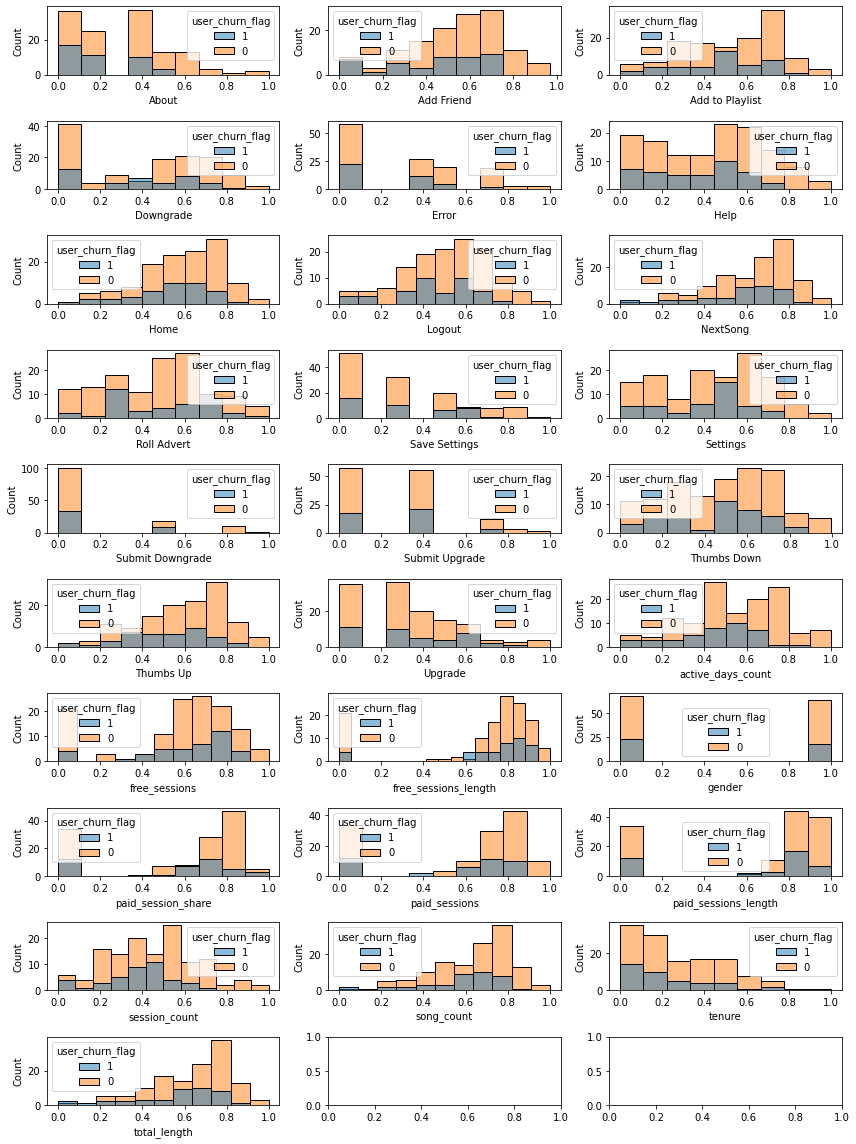

In [141]:
# Check training dataset distributions
fig, ax = plt.subplots(nx,ny, figsize = [12,16])

for i,f in enumerate(feature_names):
    ix, iy = indices[i]
    feature = training_dataset.select(select_el_udf(i)(col('features')).alias(f),col('label').alias('user_churn_flag')).toPandas()
    axi = ax[ix][iy]
    sns.histplot(feature,x=f, hue='user_churn_flag', ax = axi, hue_order=[1,0])
    #axi.set_title(f)
    plt.tight_layout()

Let's create a balanced dataset out of the training datset in order to train the models

In [142]:
# Balance modelling dataset to have same proportion of churning vs non-churning customers
churned = training_dataset.select('label').where(col('label')==1).count()
not_churned = training_dataset.select('label').where(col('label')==0).count()
ratio = int(not_churned/churned)
a = range(ratio)
# duplicate the minority rows
minor_df = training_dataset.where(col('label')==1)
major_df = training_dataset.where(col('label')==0)
oversampled_df = minor_df.withColumn("dummy", explode(array([lit(x) for x in a]))).drop('dummy')
#combine both oversampled minority rows and previous majority rows 
combined_df = major_df.unionAll(oversampled_df)

In [143]:
balanced_training_dataset = combined_df

In [144]:
features.unpersist()

DataFrame[About: bigint, Add Friend: bigint, Add to Playlist: bigint, Downgrade: bigint, Error: bigint, Help: bigint, Home: bigint, Logout: bigint, NextSong: bigint, Roll Advert: bigint, Save Settings: bigint, Settings: bigint, Submit Downgrade: bigint, Submit Upgrade: bigint, Thumbs Down: bigint, Thumbs Up: bigint, Upgrade: bigint, active_days_count: bigint, free_sessions: bigint, free_sessions_length: double, gender: bigint, paid_session_share: double, paid_sessions: bigint, paid_sessions_length: double, session_count: bigint, song_count: bigint, tenure: bigint, total_length: double, user_churn_flag: bigint]

# Modeling

In [145]:
model_names = []
metrics_valid = dict()

In [146]:
balanced_training_dataset.persist()

DataFrame[features: vector, label: bigint]

In [147]:
validation_dataset.persist()

DataFrame[features: vector, label: bigint]

In [148]:
def report_results(model, results_valid, train_time_start, train_time_end):
    
    evaluator = MulticlassClassificationEvaluator(predictionCol='prediction')
    evaluator.setLabelCol('label')
    metrics = ["weightedRecall","weightedPrecision", "accuracy", "f1" ]
    #metrics_test = []
    metrics_valid = []
    
    for m in metrics: 
        metric_valid_output = evaluator.evaluate(results_valid, {evaluator.metricName : m})
        metrics_valid.append(metric_valid_output)
    
    train_time = (train_time_end-train_time_start)/60
    
    print(model)
    print('Total training time: {} minutes'.format((train_time_end-train_time_start)/60))
    print(10*'==')
    print('Results on validation dataset')
    print(10*'-')
    print('Weighted Recall: {}'.format(metrics_valid[0]))
    print('Weighted Precision: {}'.format(metrics_valid[1]))
    print('Accuracy: {}'.format(metrics_valid[2]))
    print('F-1 Score: {}'.format(metrics_valid[3]))
    
    return metrics_valid, train_time
    

In [149]:
def get_binary_precision_recall(results_valid):
    true_positives = results_valid.where(col('prediction') == 1.0).where( col('label') == 1).count()
    false_positives = results_valid.where(col('prediction') == 1.0).where( col('label') == 0).count()
    false_negatives = results_valid.where(col('prediction') == 0.0).where( col('label') == 1).count()
    true_negatives = results_valid.where(col('prediction') == 0.0).where(col('label') == 0).count()
    
    if false_positives+true_positives == 0:
        precision = 'no user labelled churning'
    else:
        precision = true_positives/(false_positives+true_positives)
    recall = true_positives/(false_negatives+true_positives)
    print('precision: {}\nrecall: {}'.format(precision,recall))
    return precision, recall

### Baseline model: nobody churns

In [150]:
model_name = 'Baseline'
model_names.append(model_name)
bl_results_valid = validation_dataset.withColumn('prediction',lit(0).cast(DoubleType())) 

In [151]:
bl_metrics_valid, bl_train_time = report_results(model_name, bl_results_valid, 0, 0)
metrics_valid[model_name] = bl_metrics_valid+[bl_train_time]

Baseline
Total training time: 0.0 minutes
Results on validation dataset
----------
Weighted Recall: 0.7755102040816326
Weighted Precision: 0.6014160766347355
Accuracy: 0.7755102040816326
F-1 Score: 0.6774571897724607


In [152]:
p,r = get_binary_precision_recall(bl_results_valid)

precision: no user labelled churning
recall: 0.0


### Logistic Regression

In [165]:
model_name = 'Logistic Regression'
numFolds = 2
lr = LogisticRegression(maxIter=10, labelCol='label', featuresCol='features')
evaluator = MulticlassClassificationEvaluator(labelCol='label', metricName='f1')

pipeline = Pipeline(stages=[lr])
lr_paramGrid = (ParamGridBuilder()
                .addGrid(lr.regParam, [0.01, 0.5, 2]) # Regularization parameter
                .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) # Elastic net parameter
                .addGrid(lr.maxIter, [15, 20, 25]) # Number of iteration
                .build())

crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=lr_paramGrid,
    evaluator=evaluator,
    numFolds=numFolds)

lr_start = time.time()
lr_model = crossval.fit(balanced_training_dataset)
lr_end = time.time()

In [166]:
model_name = 'Logistic Regression'
model_names.append(model_name)
lr_results_valid = lr_model.transform(validation_dataset)
lr_metrics_valid, lr_train_time = report_results(model_name, lr_results_valid, lr_start, lr_end)
metrics_valid[model_name] = lr_metrics_valid+[lr_train_time]

Logistic Regression
Total training time: 2.5875924825668335 minutes
Results on validation dataset
----------
Weighted Recall: 0.6938775510204082
Weighted Precision: 0.7421923314780458
Accuracy: 0.6938775510204082
F-1 Score: 0.7114432627511098


In [167]:
p,r = get_binary_precision_recall(lr_results_valid)

precision: 0.375
recall: 0.5454545454545454


In [168]:
regPar, elNetPar, maxiter = list(lr_model.getEstimatorParamMaps()[np.argmax(lr_model.avgMetrics)].values())
print('Best model')
print(10*'-')
print('Regularization Parameter: {}'.format(regPar))
print('Elastic net Parameter: {}'.format(elNetPar))
print('Max number of iterations: {}'.format(maxiter))

Best model
----------
Regularization Parameter: 0.01
Elastic net Parameter: 0.0
Max number of iterations: 20


### Random Forest

In [187]:
model_name = 'Random Forest'
numFolds = 2
rf = RandomForestClassifier(labelCol='label', featuresCol='features',minInstancesPerNode=1)
evaluator = MulticlassClassificationEvaluator(labelCol='label', metricName='f1')

pipeline = Pipeline(stages=[rf])
rf_paramGrid = (ParamGridBuilder()
                .addGrid(rf.numTrees, [30, 40, 50, 60]) # Number of tress
                .addGrid(rf.maxDepth, [10, 20, 30]) # Maximum tree depth
                .build())

crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=rf_paramGrid,
    evaluator=evaluator,
    numFolds=numFolds,
    collectSubModels = True)

rf_start = time.time()
rf_model = crossval.fit(balanced_training_dataset)
rf_end = time.time()

In [188]:
model_name = 'Random Forest'
model_names.append(model_name)
rf_results_valid = rf_model.transform(validation_dataset)
rf_metrics_valid, rf_train_time =report_results(model_name, rf_results_valid, rf_start, rf_end)
metrics_valid[model_name] = rf_metrics_valid+[rf_train_time]

Random Forest
Total training time: 2.4173797686894734 minutes
Results on validation dataset
----------
Weighted Recall: 0.7959183673469388
Weighted Precision: 0.7692022263450835
Accuracy: 0.7959183673469388
F-1 Score: 0.765119462419114


In [189]:
p,r = get_binary_precision_recall(rf_results_valid)

precision: 0.6
recall: 0.2727272727272727


In [190]:
nt, md = list(rf_model.getEstimatorParamMaps()[np.argmax(rf_model.avgMetrics)].values())
print('Best model')
print(10*'-')
print('Number of trees: {}'.format(nt))
print('Max depth: {}'.format(md))

Best model
----------
Number of trees: 40
Max depth: 10


In [202]:
avgMetricsGrid = rf_model.avgMetrics
max(avgMetricsGrid)

0.7642977232181556

### Support Vector Machines

In [205]:
model_name = 'Support Vector Machines'
numFolds = 2
svc = LinearSVC(labelCol='label', featuresCol='features')
evaluator = MulticlassClassificationEvaluator(labelCol='label', metricName='f1')

pipeline = Pipeline(stages=[svc])
svc_paramGrid = (ParamGridBuilder()
                 .addGrid(svc.maxIter, [30, 60, 80])
                 .addGrid(svc.regParam, [0.01, 0.5, 2])
                 .addGrid(svc.threshold, [0, 0.1, 0.2])
                 .build())

crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=svc_paramGrid,
    evaluator=evaluator,
    numFolds=numFolds)

svc_start = time.time()
svc_model = crossval.fit(balanced_training_dataset)
svc_end = time.time()

In [206]:
model_name = 'Support Vector Machines'
model_names.append(model_name)
svc_results_valid = svc_model.transform(validation_dataset)
svc_metrics_valid, svc_train_time = report_results(model_name, svc_results_valid, svc_start, svc_end)
metrics_valid[model_name] = svc_metrics_valid+[svc_train_time]

Support Vector Machines
Total training time: 42.43695393403371 minutes
Results on validation dataset
----------
Weighted Recall: 0.6938775510204082
Weighted Precision: 0.7421923314780458
Accuracy: 0.6938775510204082
F-1 Score: 0.7114432627511098


In [207]:
p,r = get_binary_precision_recall(svc_results_valid)

precision: 0.375
recall: 0.5454545454545454


In [208]:
svc_maxiter, svc_regPar, svc_th = list(svc_model.getEstimatorParamMaps()[np.argmax(svc_model.avgMetrics)].values())
print('Best model')
print(10*'-')
print('Max number of iterations: {}'.format(svc_maxiter))
print('Regularization parameter: {}'.format(svc_regPar))
print('Threshold value: {}'.format(svc_th))

Best model
----------
Max number of iterations: 80
Regularization parameter: 0.01
Threshold value: 0.0


### Naive Bayes

In [213]:
model_name = 'Naive Bayes'
numFolds = 2
nb = NaiveBayes(labelCol='label', featuresCol='features', modelType="multinomial")
evaluator = MulticlassClassificationEvaluator(labelCol='label', metricName='f1')

pipeline = Pipeline(stages=[nb])
nb_paramGrid = (ParamGridBuilder()
                 .addGrid(nb.smoothing, [1.8, 2.0, 2.2, 2.4, 3, 3.2, 3.5, 4, 5, 6, 10])
                 .build())

crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=nb_paramGrid,
    evaluator=evaluator,
    numFolds=numFolds,
    collectSubModels=True)

nb_start = time.time()
nb_model = crossval.fit(balanced_training_dataset)
nb_end = time.time()

In [214]:
model_name = 'Naive Bayes'
model_names.append(model_name)
nb_results_valid = nb_model.transform(validation_dataset)
nb_metrics_valid, nb_train_time = report_results(model_name, nb_results_valid, nb_start, nb_end)
metrics_valid[model_name] = nb_metrics_valid+[nb_train_time]

Naive Bayes
Total training time: 0.26238853136698403 minutes
Results on validation dataset
----------
Weighted Recall: 0.5306122448979592
Weighted Precision: 0.7288629737609329
Accuracy: 0.5306122448979592
F-1 Score: 0.5652910447099309


In [215]:
p,r = get_binary_precision_recall(nb_results_valid)

precision: 0.2857142857142857
recall: 0.7272727272727273


In [216]:
smooth = list(nb_model.getEstimatorParamMaps()[np.argmax(nb_model.avgMetrics)].values())
print('Best model')
print(10*'-')
print('Smoothing parameter: {}'.format(smooth[0]))

Best model
----------
Smoothing parameter: 2.0


In [217]:
avgMetricsGrid = nb_model.avgMetrics
print(avgMetricsGrid)

[0.5383936914238849, 0.5533799760096301, 0.5533799760096301, 0.5496225583373967, 0.5420843153711818, 0.5420843153711818, 0.5420843153711818, 0.5468656942405844, 0.5426040135754262, 0.5387623068311764, 0.5367523464829895]


# Comparison between model performances 

In [236]:
def plot_model_performance_comparison(model_names, metrics_valid):
    
    metrics = ["Weighted Recall","Weighted Precision", "Accuracy", "F1 score" ,'Training time']
    model_count = len(model_names)

    fig, ax = plt.subplots(5,1, figsize = [5,20])

    for i,m in enumerate(metrics):

        # validation metrics
        axi = ax[i]
        axi.bar(x=model_names, height = [metrics_valid[model][i] for model in model_names])
        axi.set_title(m)
        axi.set_xticklabels(model_names,rotation = 60)
        axi.grid()
#        axi.set_xticks()
        
    plt.tight_layout()

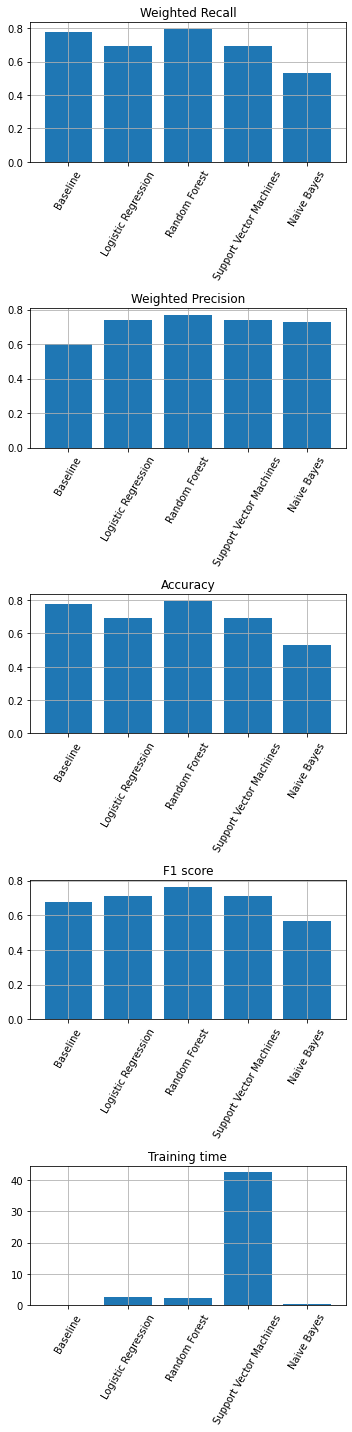

In [237]:
plot_model_performance_comparison(model_names,metrics_valid)

In [238]:
model_name_short = {'Baseline':'bl',
                    'Logistic Regression':'lr',
                    'Random Forest':'rf',
                    'Naive Bayes':'nb',
                    'Support Vector Machines':'svc',
                    'Gradient Boosted Trees':'gbt'}

In [239]:
model_list = {'lr':lr_model,
              'rf':rf_model,
              'nb':nb_model,
              'svc':svc_model,
              'gbt':gbt_model}

In [245]:
best_model_name = 'Support Vector Machines'
best_model_short_name = model_name_short[best_model_name]
best_model = model_list[best_model_short_name]
best_model_accuracy = metrics_valid[best_model_name][2]
best_model_f1 = metrics_valid[best_model_name][3]

In [246]:
# Storing best models
store = 1 
if store ==1: 
    filename = "./Best_model_"\
                +best_model_short_name\
                +"_"+"acc_"+str(best_model_accuracy)\
                +"_f1_"+str(best_model_f1)  

    best_model_extract = best_model.bestModel
    best_model_extract.write().overwrite().save(filename)

In [242]:
def plot_feature_importance(model_filename, feature_list):
    modelRead = PipelineModel.load(filename)
    
    features_imp_pd = (
    pd.DataFrame(
       modelRead.stages[0].featureImportances.toArray(), 
       index=feature_list, 
       columns=['importance'])
    )
    
    features_imp_ordered = pd.DataFrame(columns = ['features','importance'])
    features_imp_ordered['features'] = features_imp_pd.index
    features_imp_ordered['importance'] = features_imp_pd.importance.values
    features_imp_ordered = features_imp_ordered.sort_values(by='importance',ascending=False)
    
    plt.figure(figsize=[4,6], dpi=200)
    sns.barplot(data=features_imp_ordered, y = 'features',x='importance',color='b', orient = 'h')
    plt.xticks(rotation=0)

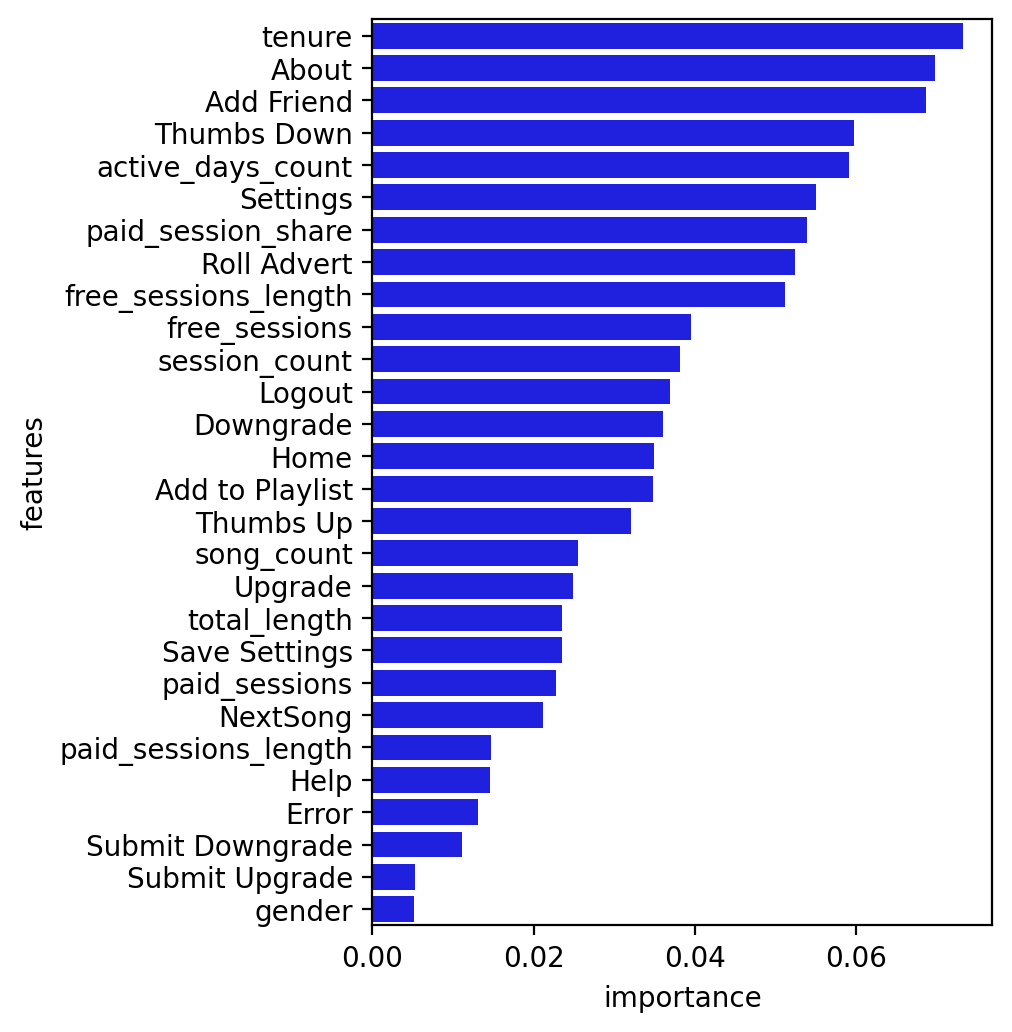

In [244]:
plot_feature_importance('Best_model_rf_acc_0.7959183673469388_f1_0.765119462419114',data.columns[0:-2])

# Conclusion

Best model obtained with Random Forest with accuracy and f1 score of 0.77 and 0.74.
This result could be way better if using a bigger dataset and leverage pyspark on a cluster. 
However due to the limited configuration available, I stayed with the small dataset on my local. 
There is a high likelihood that the results can be much better improved by increasing the amount of data to train on. 

In [104]:
extract = 1 
filename = 'Best_model_rf_acc_0.7674418604651163_f1_0.7450166112956811'
if extract==1 :
    from pyspark.ml import PipelineModel
    modelRead = PipelineModel.load(filename)

In [109]:
best_model_results = modelRead.transform(validation_dataset)
modelRead_metrics, modelRead_tt = report_results('best_model', best_model_results, 0, 0)

best_model
Total training time: 0.0 minutes
Results on validation dataset
----------
Weighted Recall: 0.6590909090909091
Weighted Precision: 0.5745920745920746
Accuracy: 0.6590909090909091
F-1 Score: 0.613947696139477
